In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

In [3]:
url = "https://raw.githubusercontent.com/d-eremina/datasets/master/DailyDelhiClimateTrain.csv"
df = pd.read_csv(url)

df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicates:", df.duplicated().sum())

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.drop_duplicates().dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

df["meanpressure"] = df["meanpressure"].clip(950, 1050)

df.info()

Shape: (1462, 5)

Dtypes:
 date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

Missing values:
 date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.2 KB


In [5]:
numeric = df.select_dtypes(include=np.number)
print(numeric.columns.tolist())

['meantemp', 'humidity', 'wind_speed', 'meanpressure']


In [6]:
summary = pd.DataFrame({
    "min": numeric.min(),
    "max": numeric.max(),
    "mean": numeric.mean(),
    "median": numeric.median(),
    "q25": numeric.quantile(0.25),
    "q50": numeric.quantile(0.50),
    "q75": numeric.quantile(0.75),
    "std": numeric.std(),
    "variance": numeric.var()
})
print(summary.round(3))

print("\nPandas describe():")
print(numeric.describe().T.round(3))

                  min       max      mean    median       q25       q50  \
meantemp        6.000    38.714    25.496    27.714    18.857    27.714   
humidity       13.429   100.000    60.772    62.625    50.375    62.625   
wind_speed      0.000    42.220     6.802     6.222     3.475     6.222   
meanpressure  950.000  1050.000  1008.116  1008.563  1001.580  1008.563   

                   q75     std  variance  
meantemp        31.306   7.348    53.995  
humidity        72.219  16.770   281.221  
wind_speed       9.238   4.562    20.808  
meanpressure  1014.945   8.513    72.477  

Pandas describe():
               count      mean     std      min       25%       50%       75%  \
meantemp      1462.0    25.496   7.348    6.000    18.857    27.714    31.306   
humidity      1462.0    60.772  16.770   13.429    50.375    62.625    72.219   
wind_speed    1462.0     6.802   4.562    0.000     3.475     6.222     9.238   
meanpressure  1462.0  1008.116   8.513  950.000  1001.580  1008.5

In [7]:
comparison = pd.DataFrame({
    "mean": numeric.mean(),
    "median": numeric.median(),
    "difference": numeric.mean() - numeric.median()
})
print(comparison.round(3))

                  mean    median  difference
meantemp        25.496    27.714      -2.219
humidity        60.772    62.625      -1.853
wind_speed       6.802     6.222       0.581
meanpressure  1008.116  1008.563      -0.448


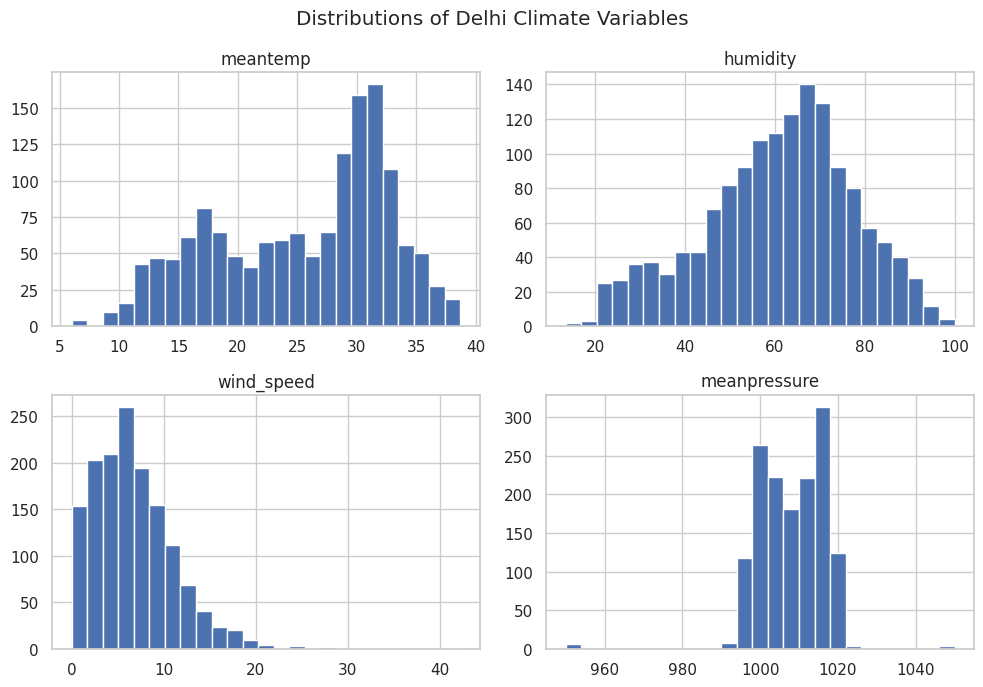

In [8]:
numeric.hist(figsize=(10, 7), bins=25)
plt.suptitle("Distributions of Delhi Climate Variables")
plt.tight_layout()
plt.show()

In [9]:
df.to_csv("delhi_climate_cleaned.csv", index=False)
print("Cleaned dataset saved. Rows:", len(df))

# =============================================================================
# Record Sheet (fill in for your lab report)
# -----------------------------------------------------------------------------
# Dataset used            : Daily Delhi Climate (Kaggle - sumanthvrao), 2013-2017
# Number of observations  : ~1462 (before cleaning)
# Key variables            : meantemp, humidity, wind_speed, meanpressure
# Main statistical result : see `summary` table above
# Important visualization : histogram grid (Cell 7)
# Main finding             : e.g. temperature is roughly symmetric; humidity/pressure
#                             show skew — compare mean vs median from Cell 6
# Limitations               : meanpressure required outlier clipping; single city only
# =============================================================================


Cleaned dataset saved. Rows: 1462
